# Проект: Исследование стартапов

* Автор: Филимонова Мария
* Дата: 10.02.2026

### Цели и задачи проекта

**Цель:** Проанализировать динамику доли возвращённых средств по различным типам финансирования в период с 2000 по 2014 год для выявления наиболее и наименее эффективных механизмов привлечения инвестиций.

**Задачи:**

- Загрузить данные из предоставленных источников и провести первичное знакомство с их структурой и качеством.

- Провести предобработку данных для обеспечения корректности анализа: обработать пропуски, дубликаты и преобразовать типы данных.

- Провести исследовательский анализ данных

- Сформулировать выводы и рекомендации для инвесторов и предпринимателей.

### Описание данных

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание датасета `cb_investments.csv`:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание датасета `cb_returns.csv`:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### Содержимое проекта

1. Загрузка данных
2. Инжиниринг признаков
3. Работа с выбросами и анализ
4. Анализ динамики
5. Итоговый вывод и рекомендации

## 1. Загрузка даных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменную cb_investments
try:
    cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
except FileNotFoundError:
    cb_investments = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Исследование стартапов/cb_investments.zip', sep=';', low_memory=False)

In [3]:
# Выгружаем данные в переменную cb_returns
try:
    cb_returns = pd.read_csv('/datasets/cb_returns.csv', index_col='year')
except FileNotFoundError:
    cb_returns = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Исследование стартапов/cb_returns.csv', index_col='year')

Познакомимся с данными датасета `cb_investments.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выводим информацию о датафрейме
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в котором представлена информация о компаниях и состоявшемся финансировании

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake_case)

- Большинство представленных данных хранятся в типе данных `object` `float64`.

- Столбец `funding_total_usd` необходимо преобразовать в целочисленный тип данных

- Столбцы `funding_round` и `participants` необходимо преобразовать в целочисленный тип данных

- Значения в столбцах `founded_at`, `founded_month` и `founded_quarter` необходимо преобразовать в тип данных дата

- Столбец `founded_year` необходимо также преобразовать в целочисленный тип данных

- Значения в столбцах `first_funding_at`, `mid_funding_at` и `last_funding_at` также необходимо преобразовать в тип данных дата

- Пропуски представлены во всех столбцах

In [6]:
# Выводим первые строки датафрейма на экран
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
# Выводим информацию о датафрейме
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


Датасет `cb_returns.csv` содержит 13 столбцов и 15 строк, в котором представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake_case)

- Типы данных столбцов представлены корректно

- Пропусков в данных нет

## 1. Предобработка данных

In [8]:
# Общее число строк в датафрейме cb_investments до предобработки
total_initial_cb_investments = len(cb_investments)

# Общее число строк в датафрейме cb_returns до предобработки
total_initial_cb_returns = len(cb_returns)

**Проверка названий столбцов в датасетах**

In [9]:
# Выводим на экран названия всех столбцов датафрейма cb_investments
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

При анализе названий столбцов обнаружена ошибка: в столбцах market и funding_total_usd присутствуют лишние пробелы в начале и конце текста.

Для обеспечения единообразия все названия столбцов будут приведены к нижнему регистру.

In [10]:
# Исправляем названия столбцов market и funding_total_usd в cb_investments
cb_investments.columns = cb_investments.columns.str.strip().str.lower()

In [11]:
# Выводим названия столбцов после обработки
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [12]:
# Выводим на экран названия всех столбцов датафрейма cb_investments
cb_returns.columns

Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Проверка названий столбцов не выявило ошибок

**Обработка столбца `funding_total_usd`**

In [13]:
# Выводим уникальные значения столбца funding_total_usd
cb_investments['funding_total_usd'].unique()

array([' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ..., ' 72,16,365 ',
       ' 5,60,248 ', nan], dtype=object)

In [14]:
# Посчитаем количество пропущенных значений
numeric_count = cb_investments['funding_total_usd'].isna().sum()
print(numeric_count)

4856


In [15]:
# Создаем временную серию без запятых для проверки на число
temp_series = cb_investments['funding_total_usd'].copy()
mask_notna = temp_series.notna()
temp_series[mask_notna] = temp_series[mask_notna].astype(str).str.replace(',', '')

# Преобразуем в числовой формат
numeric_series = pd.to_numeric(temp_series, errors='coerce')

# Находим индексы, где преобразование не удалось
non_numeric_mask = numeric_series.isna()

# Находим строки, которые содержат нечисловые значения (исключая настоящие пропуски)
non_numeric_rows_mask = non_numeric_mask & cb_investments['funding_total_usd'].notna()

# Выводим уникальные нечисловые значения
non_numeric_values = cb_investments.loc[non_numeric_rows_mask, 'funding_total_usd'].unique()

print('Уникальные нечисловые значения:')

for i, val in enumerate(non_numeric_values, 1):
    print(f"{val}")

# Выводим сумму строк с нечисловыми значениями
non_numeric_count = non_numeric_rows_mask.sum()
total_rows = numeric_count + non_numeric_count
print()
print(f'Количество строк с пропущенными нечисловыми значениями: {non_numeric_count}')
print(f'Количество строк с пропущенными числовыми значениями: {numeric_count}')
print(f'Общее количество пропущенных значений: {total_rows}')


Уникальные нечисловые значения:
 -   

Количество строк с пропущенными нечисловыми значениями: 8531
Количество строк с пропущенными числовыми значениями: 4856
Общее количество пропущенных значений: 13387


In [16]:
# Удаляем запятые
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].str.replace(',', '', regex=True)

# Преобразовываем в числовой формат
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'], errors='coerce')

# Выводим первые 20 значений
print(cb_investments['funding_total_usd'].head(20))

0      90000000.0
1       2000000.0
2       9000000.0
3       7700000.0
4        540000.0
5      19000000.0
6      12000000.0
7       8700000.0
8       6000000.0
9       3500000.0
10     28000000.0
11      2705000.0
12      8900000.0
13            NaN
14      8000000.0
15            NaN
16      3900000.0
17    750500000.0
18      2000000.0
19            NaN
Name: funding_total_usd, dtype: float64


**Преобразование столбцов с полными датами**

In [17]:
# Преобразуем столбцы с полными датами в формат datetime
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns:
    # Преобразуем в datetime
    cb_investments[col] = pd.to_datetime(cb_investments[col], errors='coerce', format='%Y-%m-%d')

**Обработка текстовых данных**

In [18]:
# Составляем список со столбцами, которые содержат текст
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 
               'country_code', 'state_code', 'region', 'city']

for col in text_columns:
    # В каждом столбце удаляем лишние пробелы и приводим к нижнему регистру
    cb_investments[col] = cb_investments[col].str.strip().str.lower()

In [19]:
# Создаем словарь с заглушками для столбцов с текстовыми данными
fill_values = {
    'name': 'unknown',
    'homepage_url': 'no_website',
    'category_list': 'unknown',
    'market': 'other',
    'status': 'unknown',
    'country_code': 'unknown',  
    'state_code': 'unknown',
    'region': 'unknown',
    'city': 'unknown'
}

# Заполняем пропуски
cb_investments.fillna(value=fill_values, inplace=True)

In [20]:
# Выводим результат
print('Пропуски после обработки:')
print(cb_investments[text_columns].isna().sum())

Пропуски после обработки:
name             0
homepage_url     0
category_list    0
market           0
status           0
country_code     0
state_code       0
region           0
city             0
dtype: int64


**Обработка полных дубликатов**

In [21]:
# Проверяем количество полных дубликатов в датафрейме cb_investments
duplicate_count = cb_investments.duplicated().sum()
print(f'Количество полных дубликатов: {duplicate_count}')

Количество полных дубликатов: 4855


In [22]:
# Удаление полных дубликатов
cb_investments.drop_duplicates(inplace=True)

In [23]:
# Выводим результат
print(f'После удаления полных дубликатов: {len(cb_investments)}')

После удаления полных дубликатов: 49439


In [24]:
# Проверяем количество полных дубликатов в датафрейме cb_returns
duplicate_count = cb_returns.duplicated().sum()
print(f'Количество полных дубликатов: {duplicate_count}')

Количество полных дубликатов: 0


**Обработка пропусков в funding_total_usd**

In [25]:
# Фильтруем исходный датафрейм cb_investments, избавляясь от строк в стобце funding_total_usd, в которых либо значение Nan, либо 0
cb_investments = cb_investments[
    cb_investments['funding_total_usd'].notna() & 
    (cb_investments['funding_total_usd'] > 0)
].copy()

# Проверяем итог
print(f'Осталось строк после фильтрации: {len(cb_investments)}')

Осталось строк после фильтрации: 40907


In [26]:
# Подсчет количество пропущенных значений после обработки
cb_investments['funding_total_usd'].isna().sum()

np.int64(0)

**Обработка столбца `mid_funding_at`**

In [27]:
# Создаём маску для строк, где mid_funding_at — NaN, но есть first и last
valid_interval = (
    cb_investments['mid_funding_at'].isna() &
    cb_investments['first_funding_at'].notna() &
    cb_investments['last_funding_at'].notna()
)

In [28]:
# Вычисляем середину интервала для подходящих строк
cb_investments.loc[valid_interval, 'mid_funding_at'] = (
    cb_investments['first_funding_at'] + 
    (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2
)

### Промежуточные выводы

In [29]:
# Число строк после очистки в датафрейме cb_investments
total_final_cb_investments = len(cb_investments)

# Процент отброшенных строк в даьафрейме cb_investments
discarded_percent_cb_investments = ((total_initial_cb_investments - total_final_cb_investments) / total_initial_cb_investments) * 100

# Число строк после очистки в датафрейме cb_returns
total_final_cb_returns = len(cb_returns)

# Процент отброшенных строк в даьафрейме cb_investments
discarded_percent_cb_returns = ((total_initial_cb_returns - total_final_cb_returns) / total_initial_cb_returns) * 100

print('1. Общая статистика для датафрейма cb_investments:')
print(f'Исходное количество строк: {total_initial_cb_investments}')
print(f'Осталось после фильтрации: {total_final_cb_investments}')
print(f'Отброшено: {total_initial_cb_investments - total_final_cb_investments} строк ({discarded_percent_cb_investments:.1f}%)')

print()
print('2. Общая статистика для датафрейма cb_returns:')
print(f'Исходное количество строк: {total_initial_cb_returns}')
print(f'Осталось после фильтрации: {total_final_cb_returns}')
print(f'Отброшено: {total_initial_cb_returns - total_final_cb_returns} строк ({discarded_percent_cb_returns:.1f}%)')


1. Общая статистика для датафрейма cb_investments:
Исходное количество строк: 54294
Осталось после фильтрации: 40907
Отброшено: 13387 строк (24.7%)

2. Общая статистика для датафрейма cb_returns:
Исходное количество строк: 15
Осталось после фильтрации: 15
Отброшено: 0 строк (0.0%)


**1. Анализ отброшенных данных**

- Датафрейм cb_investments:

    - Исходно: 54 294 строки.

    - После фильтрации: 40 907 строк.

    - Отброшено: 13 387 строк (24,7 %).

- Датафрейм cb_returns:

    - Исходно: 15 строк.

    - После фильтрации: 15 строк.

    - Отброшено: 0 строк (0 %).

**2. Полнота данных:**

- Потери данных приемлемы: 24.7% отброшенных строк в cb_investments — это умеренный уровень потерь для этапа очистки реальных данных.

- Объём сохранённых данных достаточен: 40,907 записей предоставляют хорошую статистическую основу для анализа.

- Качество данных улучшено: Удалены дубликаты и некорректные записи, что повышает надёжность выводов.

## 2. Инжиниринг признаков

### 2.1 Группы по срокам финансирования

**Разделим все компании на три группы**

In [30]:
# Установим первоначальное значение
cb_investments['funding_type'] = 'Срок финансирования более года'

# Корректируем классификацию для компаний
cb_investments.loc[(cb_investments['last_funding_at'] - cb_investments['first_funding_at']).dt.days < 365, 'funding_type'] = 'Срок финансирования до года'

# Отдельно выделяем компании с единичным финансированием
cb_investments.loc[cb_investments['funding_rounds'] == 1, 'funding_type'] = 'Единичное финансирование'

In [31]:
# Выводим уникальные значения
cb_investments['funding_type'].unique()

array(['Единичное финансирование', 'Срок финансирования до года',
       'Срок финансирования более года'], dtype=object)

In [32]:
# Задаем список цветов для дальнейшей визуализации
colors_list = ['green', 'orange', 'blue']

# Задаем порядок категории
fund_type_order = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

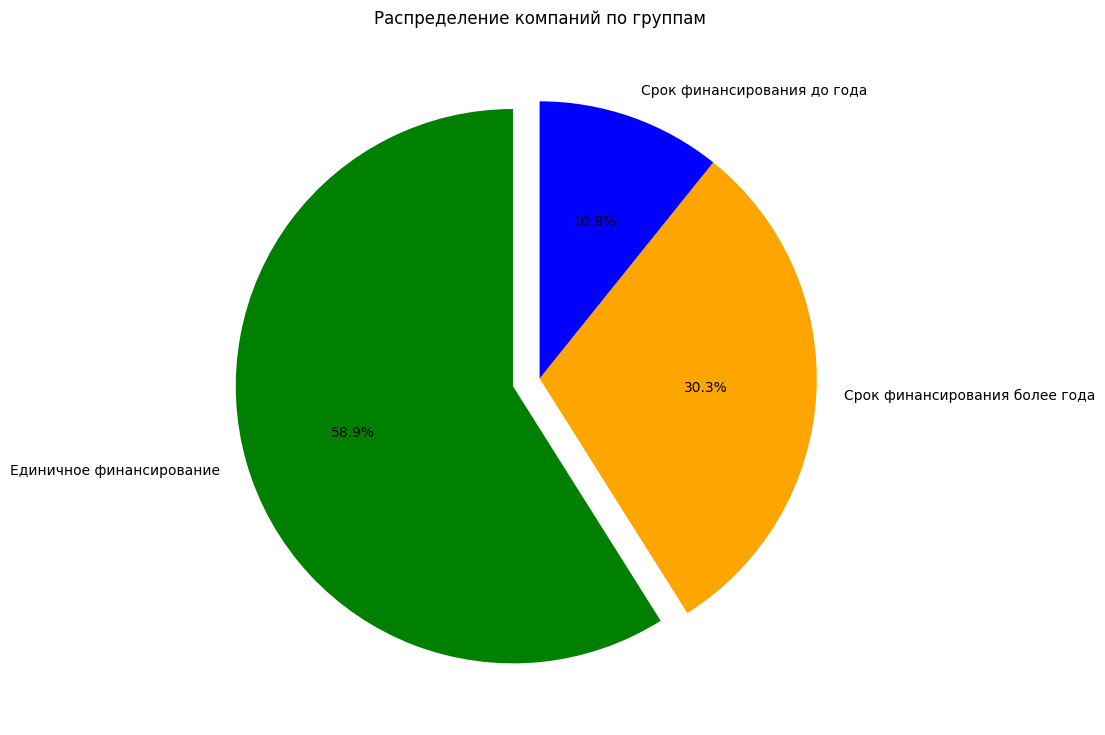

In [33]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Посчитаем и отсортируем количество записей по категориям
group_counts = cb_investments['funding_type'].value_counts().sort_values(ascending=False)


# Создаем круговой график
explode = (0.1, 0, 0)
plt.pie(
    group_counts,
    explode=explode,
    labels=group_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_list
)

# # Настраиваем оформление графика
plt.title('Распределение компаний по группам')

# Выводим визуализированные данные
plt.show()

**Выводы:**

- Лидирующей категорией является "Единичное финансирование" и составляет 58,9%

    - это указывает на преобладание краткосрочных или разовых инвестиционных проектов, где компании не привлекали дополнительные раунды финансирования

- Вторая по величине категория - "Срок финансирования более года" (30,3%)

- Наименьшая категория - "Срок финансирования до года" (10,8%)

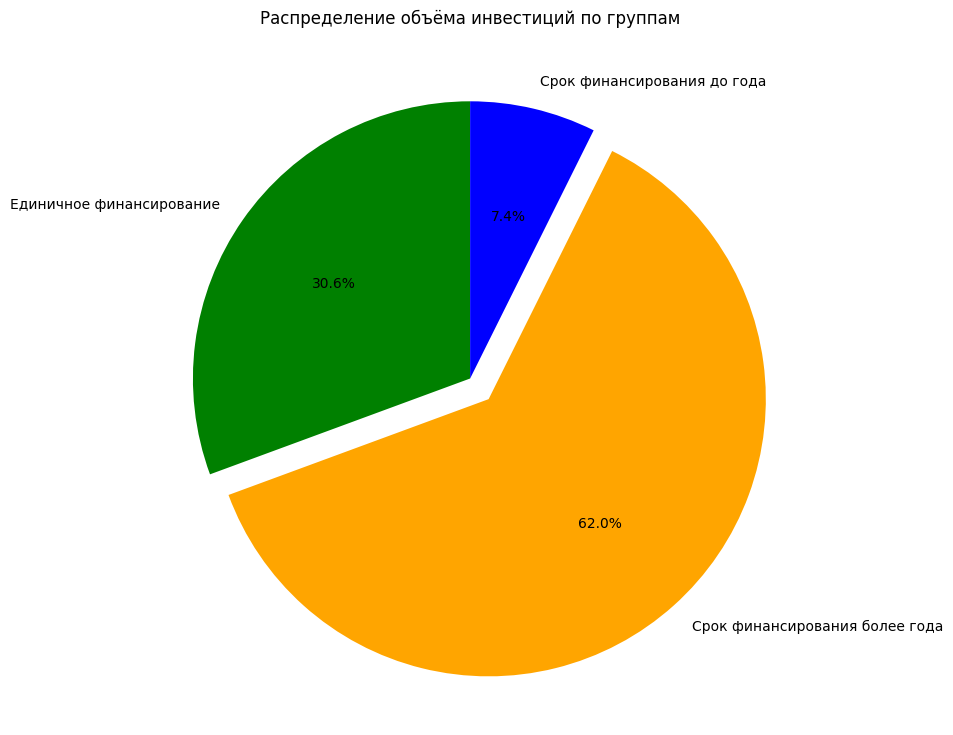

In [34]:
# Посчитаем сумму инвестиций по категориям
grouped_funding_type = cb_investments.groupby('funding_type')['funding_total_usd'].sum()

# Задаем размер графика
plt.figure(figsize = (12, 9))

# Создаем круговой график
explode = (0, 0.1, 0)
plt.pie(
    grouped_funding_type,
    explode=explode,
    labels=grouped_funding_type.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_list
)

# Настраиваем оформление графика
plt.title('Распределение объёма инвестиций по группам')

# Выводим визуализированные данные
plt.show()

**Выводы:**

- Лидирующей категорией является "Срок финансирования более года" и составляет 62%

    - большая часть инвестиционных средств (более половины объёма) направлена на проекты с длительным сроком финансирования (более года)

- Вторая по величине категория - "Единичное финансирование" (30,6%)

- Наименьшая категория - "Срок финансирования до года" (7,4%)

### 2.2 Выделение средних и нишевых сегментов рынка

In [35]:
# Посчитаем количество компаний по сегментам рынка
distribution = cb_investments['market'].value_counts().sort_values(ascending=False)

print('Количество компаний по сегментам рынка:')
print(distribution)

Количество компаний по сегментам рынка:
market
software                 4812
biotechnology            3590
other                    2503
mobile                   2344
e-commerce               1866
                         ... 
law enforcement             1
real estate investors       1
business productivity       1
musicians                   1
gold                        1
Name: count, Length: 395, dtype: int64


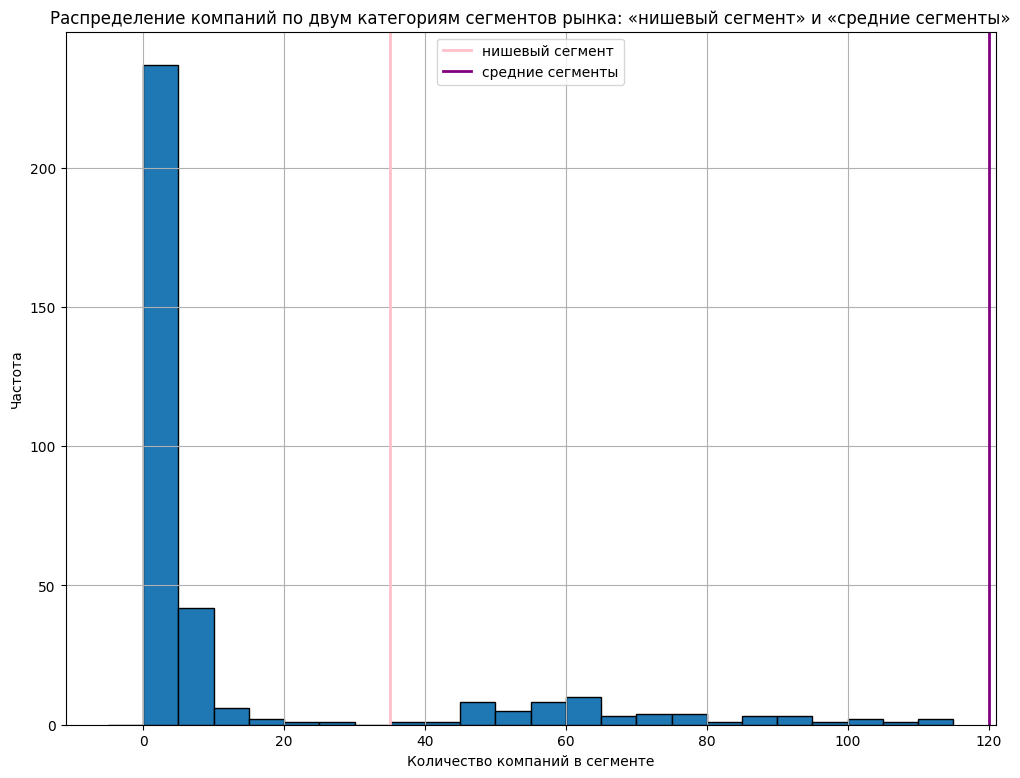

In [36]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим гистограмму распределения данных
distribution.hist(
    bins=range(-5, 120, 5),
    edgecolor='black' 
)

# Добавляем вертикальные линии-разделители для сегментов рынка
plt.axvline(
    x=35,
    color='pink',
    linewidth=2,
    label='нишевый сегмент')

plt.axvline(
    x=120,
    color='purple',
    linewidth=2,
    label='средние сегменты')

# Настраиваем легенду
plt.legend()

# Настраиваем оформление графика
plt.title('Распределение компаний по двум категориям сегментов рынка: «нишевый сегмент» и «средние сегменты»')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота')

# Добавляем сетку на график
plt.grid(True)

# Выводим визуализированные данные
plt.show()


**Выводы:**

- Большая часть компаний сосредоточена в «нишевом сегменте»

- Самый высокий пик частоты (более 200) наблюдается в диапазоне 0–5 компаний в сегменте, что говорит о преобладании мелких, узкоспециализированных сегментов рынка

In [37]:
# Создаем функцию 
def categorize_count(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

# Применяем функцию categorize_count к каждому элементу distribution с помощью apply
category_series = distribution.apply(categorize_count)

In [38]:
# Считаем количество сегментов по категориям
category_counts = category_series.value_counts()

# Выводим результат
print('Количество сегментов по категориям:')
print(category_counts)

Количество сегментов по категориям:
count
нишевый     289
средний      57
массовый     49
Name: count, dtype: int64


**Выводы:**

- Лидирующей категорией является "нишевая", и она составляет 289

**Разделим сегменты на категории на основе количества компаний в каждом сегменте**

In [39]:
# Создаем функцию 
def transform_segment(segment_name):
    # Получаем значение по индексу
    count = distribution[segment_name]

    # Классифицируем по количеству компаний
    if count > 120:
        return segment_name  
    elif count >= 35:
        return 'mid'        
    else:
        return 'niche'     


# Применяем функцию к столбцу market
cb_investments['market'] = cb_investments['market'].apply(transform_segment)


**Вывод:**

- Была реализована функция, которая делит рыночные сегменты на три категории по количеству компаний

    - Если больше 120 компаний, то функция возвращает исходное название

    - От 35 до 120 - присваивает новое название `mid`

    - Если меньше 35, то также присваивает новое название `niche`

## 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

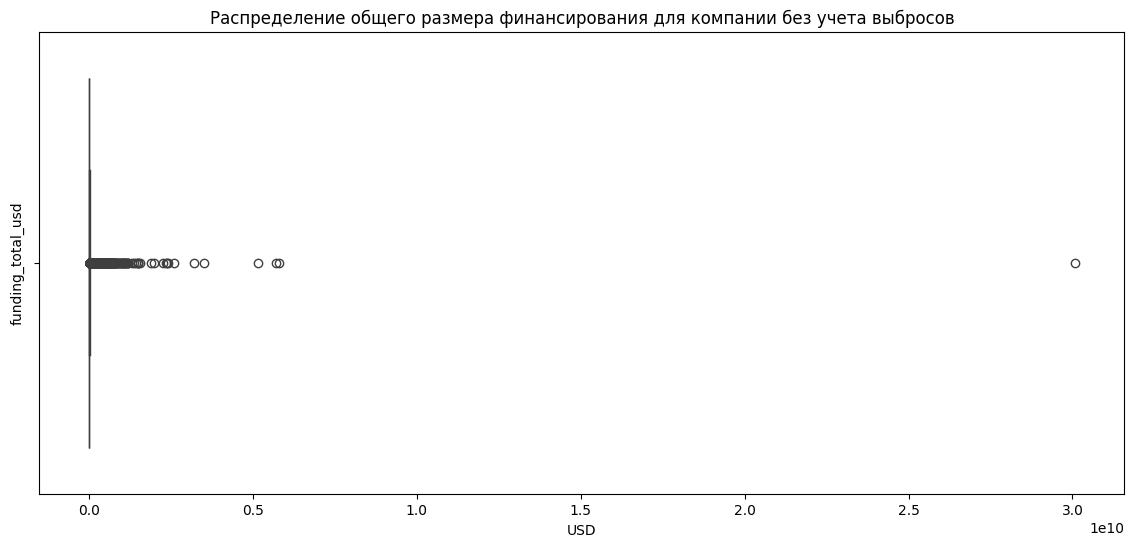

In [40]:
# Задаем размер графика
plt.figure(figsize=(14, 6))

# Строим график "ящик с усами"
sns.boxplot(x=cb_investments['funding_total_usd'])

# Настраиваем оформление графика
plt.title('Распределение общего размера финансирования для компании без учета выбросов')
plt.xlabel('USD')
plt.ylabel('funding_total_usd')

# Выводим визуализированные данные
plt.show()

Из-за большого количества выбросов, сложно сделать выводы по графику, так как его плохо видно, поэтому визуализируем данные, исключив выбросы

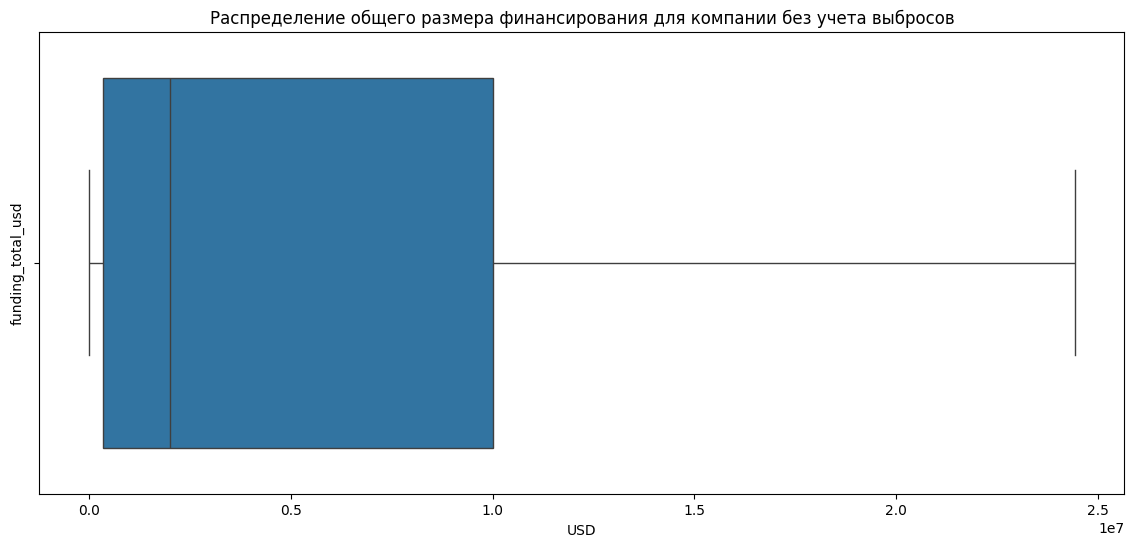

In [41]:
# Задаем размер графика
plt.figure(figsize=(14, 6))

# Строим график "ящик с усами"
sns.boxplot(x=cb_investments['funding_total_usd'], showfliers=False)

# Настраиваем оформление графика
plt.title('Распределение общего размера финансирования для компании без учета выбросов')
plt.xlabel('USD')
plt.ylabel('funding_total_usd')

# Выводим визуализированные данные
plt.show()

**Выводы:**

- Наблюдается правосторонняя ассиметрия. Большинство значений сконцентрировано в нижней части диапазона, а высокие значения встречаются эпизодически.

In [42]:
# Группируем данные по сегменту рынка и анализируем статистические характеристики финансирования
ftu_describe = cb_investments['funding_total_usd'].describe()

# Выводим общую статистику по всем сегментам
print("Общая статистика:")
print(ftu_describe)

Общая статистика:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


**Вывод:**

- Финансирование > 24.5 млн USD можно считать аномально высоким (экстремальные сделки).

- Всё, что между 350 тыс. и 24.5 млн USD — диапазон "обычных" значений.

- Типичное значение: 2 млн USD

- Значения < 350 тыс. USD — относительно низкие

Определим компании с аномальным объёмом общего финансирования

In [43]:
# Выведем уникальные значения столбца market
markets = cb_investments['market'].unique()

print(markets)

['education' 'other' 'mid' 'social media' 'hardware + software'
 'biotechnology' 'hospitality' 'enterprise software' 'manufacturing'
 'finance' 'design' 'niche' 'nonprofits' 'software' 'curated web'
 'health care' 'health and wellness' 'clean technology' 'web hosting'
 'e-commerce' 'automotive' 'medical' 'fashion' 'security' 'networking'
 'analytics' 'semiconductors' 'public relations' 'travel' 'consulting'
 'real estate' 'technology' 'music' 'advertising' 'games' 'mobile'
 'internet' 'sports' 'photography' 'news' 'search' 'messaging' 'video'
 'marketplaces' 'entertainment' 'saas' 'cloud computing' 'big data' 'apps'
 'social network media' 'startups']


In [44]:
# Установим первоначальное значение
cb_investments['anomaly'] = False

In [45]:
for market_type in markets:
    # Оставляем записи, относящиеся только к текущему типу рынка
    segment_data = cb_investments[cb_investments['market'] == market_type]

    # Расчитывает 1-й и 3-й квартили
    Q1 = segment_data['funding_total_usd'].quantile(0.25)
    Q3 = segment_data['funding_total_usd'].quantile(0.75)

    # Вычисляем межквартальный размах
    IQR = Q3 - Q1

    # Определяем нижнюю и верхние границы
    lower_bound = Q1 - 1.5 * IQR
    upper_bound  =  Q3 + 1.5 * IQR

    # Находим индексы строк, где финансирование выходит за границы
    outlier_mask = ((cb_investments['market'] == market_type) & ((cb_investments['funding_total_usd'] < lower_bound) | (cb_investments['funding_total_usd'] > upper_bound)))
    
    # Помечаем аномалии в исходном DataFrame
    cb_investments.loc[outlier_mask, 'anomaly'] = True

# Выводим количество аномалий
print('Количество обнаруженных аномалий:', cb_investments['anomaly'].sum())


Количество обнаруженных аномалий: 5244


In [46]:
# Группируем и вычисляем среднее значение
anomaly = cb_investments.groupby('market')['anomaly'].mean().round(2).reset_index()

# Выводим результат
print(anomaly)

                  market  anomaly
0            advertising     0.12
1              analytics     0.12
2                   apps     0.14
3             automotive     0.14
4               big data     0.15
5          biotechnology     0.11
6       clean technology     0.13
7        cloud computing     0.16
8             consulting     0.17
9            curated web     0.12
10                design     0.11
11            e-commerce     0.14
12             education     0.13
13   enterprise software     0.11
14         entertainment     0.17
15               fashion     0.13
16               finance     0.13
17                 games     0.10
18   hardware + software     0.12
19   health and wellness     0.13
20           health care     0.11
21           hospitality     0.13
22              internet     0.15
23         manufacturing     0.11
24          marketplaces     0.15
25               medical     0.14
26             messaging     0.13
27                   mid     0.14
28            

In [47]:
# Сортируем данные
top_segments = anomaly.sort_values('anomaly', ascending=False)

# Выводим результат
print(top_segments.head(10))

             market  anomaly
8        consulting     0.17
14    entertainment     0.17
37      real estate     0.17
38             saas     0.16
35      photography     0.16
47       technology     0.16
39           search     0.16
32            niche     0.16
49            video     0.16
7   cloud computing     0.16


**Выводы:**

- `consulting` , `entertainment`, `real estate` имеют одинаковый показатель аномалий — 0.17 (17%). Это самые «проблемные» сегменты в выборке, где наблюдается наибольшая доля отклонений от нормы

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [48]:
# Список колонок с датами, которые нужно проверить
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Отбираем записи, где хотя бы одна из дат приходится на 2014 год
df_2014 = cb_investments[(cb_investments['founded_at'].dt.year == 2014) | (cb_investments['first_funding_at'].dt.year == 2014) | (cb_investments['mid_funding_at'].dt.year == 2014) | (cb_investments['last_funding_at'].dt.year == 2014)]

# Выводим объём данных
print(f'Количество записей с датами в 2014 г.: {len(df_2014)}')
print(f'Доля от общего числа записей: {len(df_2014) / len(cb_investments):.2%}')
print()

# Проверяем, есть ли такие записи 
if len(df_2014) == 0:
    print('Нет записей с датами в 2014 г. → данные за 2014 г. неполные')
else:
    # Находим самые поздние (максимальные) даты по каждой колонке
    max_dates = df_2014[date_cols].max()
    
    print('Максимальные даты по категориям для записей с хотя бы одной датой в 2014 г.:')
    
    # Выводим каждую дату, если она есть
    for col, max_date in max_dates.items():
        if pd.notna(max_date):  # если дата не пропущена
            print(f"{col}: {max_date.strftime('%Y-%m-%d')}")
        else:
            print(f'{col}: Нет данных')


Количество записей с датами в 2014 г.: 11984
Доля от общего числа записей: 29.30%

Максимальные даты по категориям для записей с хотя бы одной датой в 2014 г.:
founded_at: 2014-12-13
first_funding_at: 2014-12-31
mid_funding_at: 2014-12-31
last_funding_at: 2014-12-31


**Вывод:**

На основании проведённого анализа можно сделать следующие выводы о полноте данных за 2014 год:

- Общий охват данных

    - В выборке присутствует 10 028 записей (28,18 % от общего объёма), содержащих хотя бы одно событие 2014 года. Это значительная часть данных, позволяющая делать обоснованные выводы.

- Временной охват

    - Максимальные даты во всех категориях (founded_at, first_funding_at, mid_funding_at, last_funding_at) приходятся на декабрь 2014, что подтверждает наличие данных за весь календарный год.

In [49]:
# Считаем распределение по столбцу anomaly
anomaly_col = cb_investments['anomaly'].value_counts(dropna=False)

# Выводим результат
print("Распределение по столбцу 'anomaly':")
print(anomaly_col)

Распределение по столбцу 'anomaly':
anomaly
False    35663
True      5244
Name: count, dtype: int64


In [50]:
# Выводим исходное количество записей в датасете
print(f"Исходное число записей: {len(cb_investments)}")

# Подсчитываем количество аномальных записей
print(f"Число аномальных записей: {cb_investments['anomaly'].sum()}")

# Фильтруем датасет, исключая аномальные записи
cb_investments = cb_investments[cb_investments['anomaly'] == False]

# Выводим количество оставшихся записей после фильтрации
print(f"Оставшееся число записей: {len(cb_investments)}")

Исходное число записей: 40907
Число аномальных записей: 5244
Оставшееся число записей: 35663


**Вывод:**

- В датафрейме изначально было 40907 записей — это полная выборка данных до фильтрации.

- Распределение по признаку `anomaly`:

    - Большинство записей (35663) помечены как False — то есть не содержат аномалий. Это основная «чистая» часть датасета, пригодная для дальнейшего анализа.

    - Меньшая часть (5244) помечена как True — это аномальные записи. Они составляют заметную часть

- После фильтрации аномалий осталось 35663 записи

In [51]:
# Выделяем год из столбца mid_funding_at
cb_investments['mid_funding_year'] = cb_investments['mid_funding_at'].dt.year

In [52]:
# Преобразовываем столбец mid_funding_year к целочисленному типу
cb_investments['mid_funding_year'] = cb_investments['mid_funding_year'].astype('Int64')

In [53]:
# Группируем данные по году проведения раунда финансирования
yearly_funding = cb_investments.groupby('mid_funding_year')['funding_rounds'].sum().reset_index()

# Выводим результат
print("Суммарное количество раундов финансирования по годам:")
print(yearly_funding)

Суммарное количество раундов финансирования по годам:
    mid_funding_year  funding_rounds
0               1921             1.0
1               1960             2.0
2               1979             1.0
3               1982             3.0
4               1983             1.0
5               1984             2.0
6               1985             3.0
7               1987             2.0
8               1989             1.0
9               1990             1.0
10              1992             5.0
11              1993             1.0
12              1994             4.0
13              1995             9.0
14              1996             8.0
15              1997             5.0
16              1998            15.0
17              1999            43.0
18              2000           113.0
19              2001            66.0
20              2002            98.0
21              2003           125.0
22              2004           181.0
23              2005           948.0
24              2006 

In [54]:
# Фильтруем датафрейм оставляем только строки, где количество раундов >= 50
valid_years = yearly_funding[yearly_funding['funding_rounds'] >= 50]['mid_funding_year'].tolist()

# Выводим результат
print('Годы, в которых больше или равно 50 раундам:')
print(valid_years)

Годы, в которых больше или равно 50 раундам:
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [55]:
# Фильтруем исходный датафрейм, оставляя те строки, в которых присутствуют значения из valid_years
cb_investments = cb_investments[cb_investments['mid_funding_year'].isin(valid_years)]

**Вывод:**

- Из столбца `mid_funding_at` успешно извлечены годы проведения раундов финансирования и сохранены в новый столбец

- Проведена группировка данных по годам с подсчётом суммарного количества раундов финансирования для каждого года

- Выделены годы, в которых количество раундов ≥ 50. В результате получился период с 2000 по 2014 года

- Данные за годы с низкой активностью исключены из дальнейшего анализа

### 3.3. Анализ типов финансирования по объёму и популярности

In [56]:
# Список типов финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммируем и сортируем объём финансирования по типам
total_amounts = cb_investments[funding_types].sum().sort_values(ascending=True)

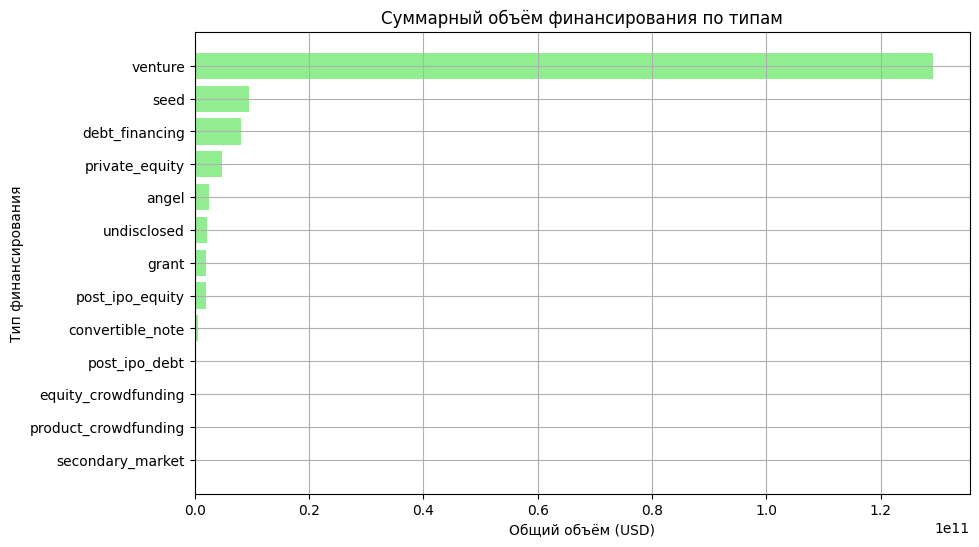

In [57]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Создаем горизонтальныю столбчатую диаграмму
plt.barh(
    total_amounts.index,
    total_amounts.values,
    color = 'lightgreen'
)

# Настраиваем оформление графика
plt.title('Суммарный объём финансирования по типам')
plt.xlabel('Общий объём (USD)')
plt.ylabel('Тип финансирования')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Лидирующим типом финансирования является venture

- Значительно меньшие объёмы у остальных категорий

In [58]:
# Подсчитываем, сколько раз каждый тип финансирования встречался в данных
popularity_counts = (cb_investments[funding_types] > 0).sum().sort_values(ascending=True)


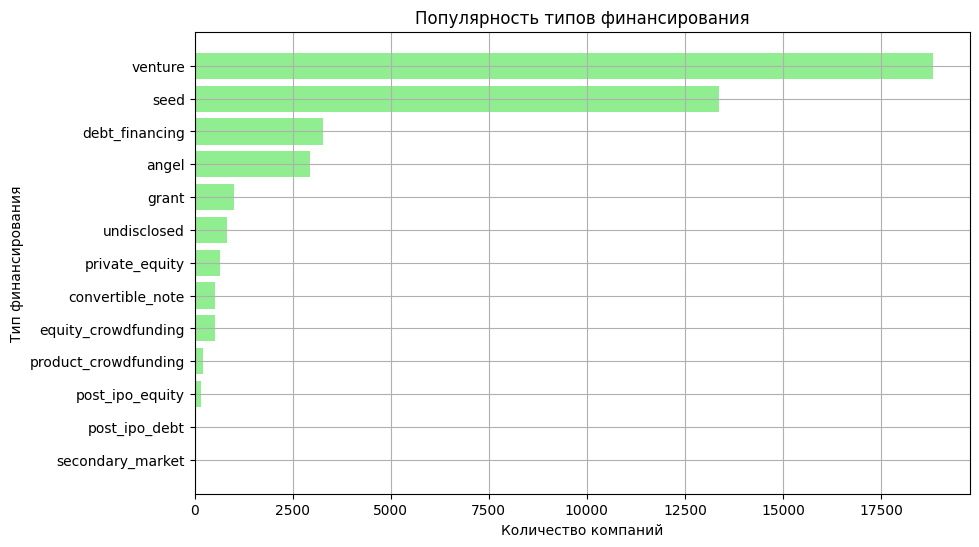

In [59]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Создаем столбчатую диаграмму
plt.barh(
    popularity_counts.index,
    popularity_counts.values,
    color = 'lightgreen'
)

# Настраиваем оформление графика
plt.title('Популярность типов финансирования')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наиболее популярными типами финансирования являются venture и seed

In [60]:
# Суммируем возвраты по каждому типу за весь период
total_returns = cb_returns[funding_types].sum().sort_values(ascending=True)

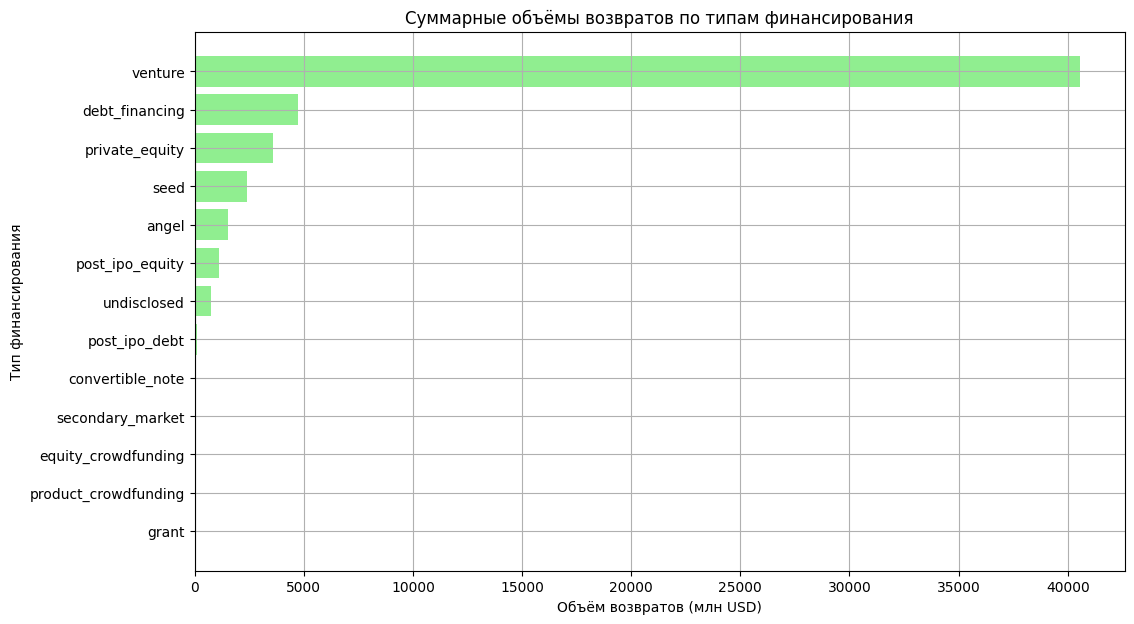

In [61]:
# Задаем размер графика
plt.figure(figsize=(12, 7))

# Создаем столбчатую диаграмму
plt.barh(
    total_returns.index,
    total_returns.values,
    color = 'lightgreen'
)

# Настраиваем оформление графика
plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Объём возвратов (млн USD)')
plt.ylabel('Тип финансирования')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наиболее популярным типом финансирования по возвратам является venture

- Менее популярными типами финансирования по возврату средств являются dept_financing, private_equity

- Самыми непопулярными типами финансирования по возвратам средств являются grant, product_crowdfunding, equity_crowdfunding, secondary_market, convertible_note и post_ipo_debt

## 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

In [62]:
# Анализируем суммарные объёмы возвратов по типам финансирования
cb_investments['avg_round_size_usd'] = (cb_investments['funding_total_usd'].fillna(0) / cb_investments['funding_rounds'])

# Выводим результат
print('Средний размер раунда финансирования:')
print(cb_investments['avg_round_size_usd'])

Средний размер раунда финансирования:
1        2.000000e+06
2        9.000000e+06
3        2.566667e+06
4        5.400000e+05
7        8.700000e+06
             ...     
49430    1.500000e+06
49433    1.500000e+06
49434    9.000000e+06
49435    2.500000e+05
49437    1.150000e+04
Name: avg_round_size_usd, Length: 35588, dtype: float64


In [63]:
# Анализируем средние размеры раундов финансирования и общие число раундов по годам
annual_data = cb_investments.groupby('mid_funding_year').agg(avg_round_size=('avg_round_size_usd', 'mean'),total_rounds=('funding_rounds', 'sum')).reset_index()

# Выводим результат
print('Анализ раундов финансирования по годам:')
print(annual_data)

Анализ раундов финансирования по годам:
    mid_funding_year  avg_round_size  total_rounds
0               2000    4.492723e+06         113.0
1               2001    3.366817e+06          66.0
2               2002    4.053461e+06          98.0
3               2003    3.099490e+06         125.0
4               2004    4.616702e+06         181.0
5               2005    5.801089e+06         948.0
6               2006    5.346925e+06        1849.0
7               2007    4.678782e+06        2842.0
8               2008    4.322739e+06        3663.0
9               2009    3.517328e+06        4617.0
10              2010    3.188317e+06        6136.0
11              2011    2.598416e+06        7578.0
12              2012    2.035770e+06        9707.0
13              2013    1.976610e+06       12880.0
14              2014    2.203065e+06        7122.0


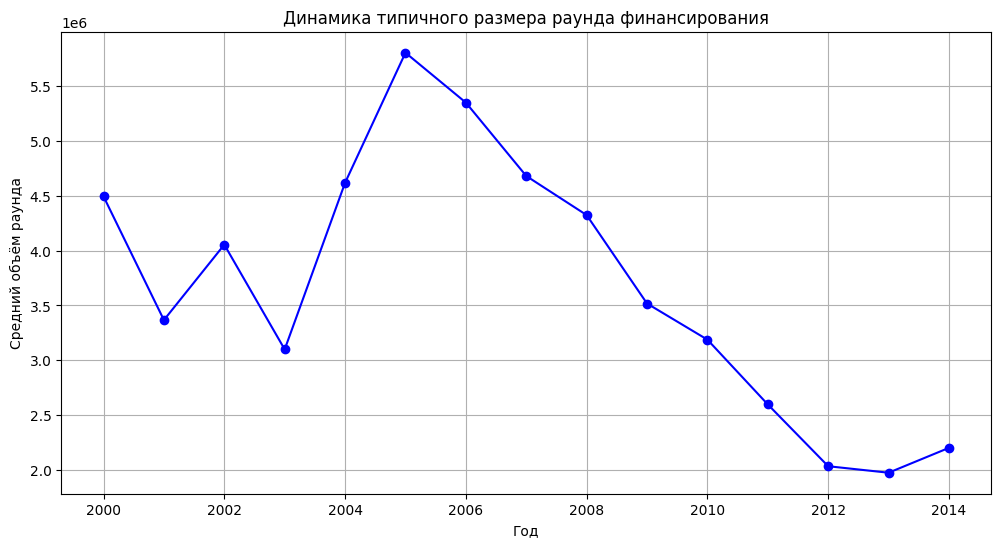

In [64]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Создаем линейный график
plt.plot(
    annual_data['mid_funding_year'],
    annual_data['avg_round_size'],
    marker='o',
    linestyle='-',
    color='blue'
)

# Настраиваем оформление графика
plt.title('Динамика типичного размера раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Средний объём раунда')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Пик финансирования приходится на 2005 год

- С 2003 года по 2005 наблюдается рост

- После 2005 года наблюдается постепенное снижение среднего размера раундов

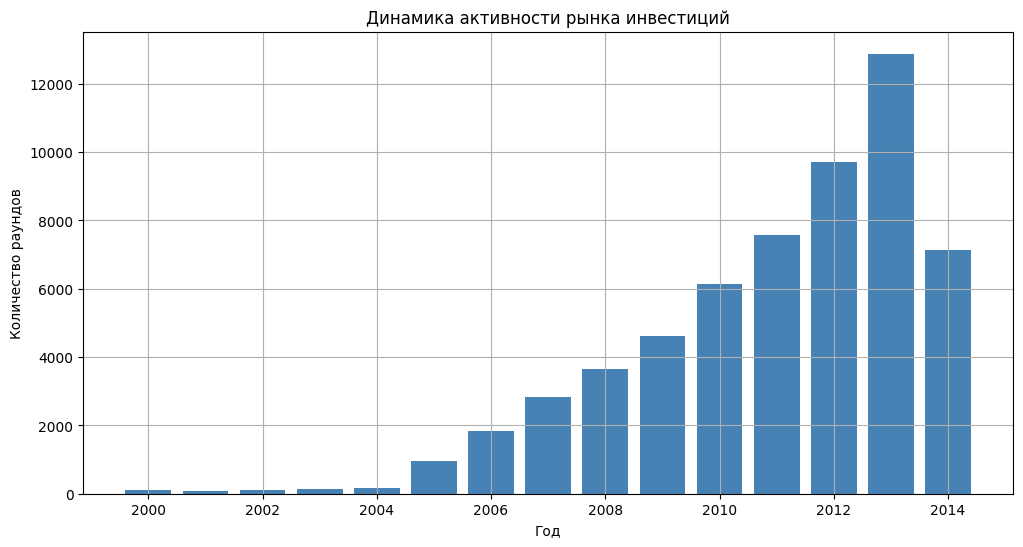

In [65]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Создаем горизонтальную столбчатую диаграмму
plt.bar(
    annual_data['mid_funding_year'],
    annual_data['total_rounds'],
    color='steelblue'
)

# Настраиваем оформление графика
plt.title('Динамика активности рынка инвестиций')
plt.xlabel('Год')
plt.ylabel('Количество раундов')

# Добавляем сетку шрафика
plt.grid()

# Выводим визуализированные данные
plt.show()


**Вывод:**

- На 2000-2004 года приходятся самые низкие значения, что может указывать на неразвитую инфраструктуру рынка инвестиций

- В 2005-2012 годах наблюдается заметный скачок в активности: количество раундов удваивается по сравнению с предыдущими годами

- Пик активности приходится на 2013 год

- А после 2013 года наблюдается небольшое снижение темпов роста

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [66]:
# Выбираем сегменты рынка с категорией «массовый»
massive_segments = []
for seg, cat in category_series.items(): 
    if cat == 'массовый':
        massive_segments.append(seg)

# Фильтруем данные — оставляем только инвестиции в «массовые» сегменты
cb_massive = cb_investments[cb_investments['market'].isin(massive_segments)]

# Считаем суммарное финансирование по годам и сегментам
annual_funding = cb_massive.groupby(['mid_funding_year', 'market'])['funding_total_usd'].sum().reset_index()

# Создаем сводную таблицу
pivot_table = annual_funding.pivot(
    index='mid_funding_year',
    columns='market',
    values='funding_total_usd'
).fillna(0).sort_index()


In [67]:
# Выводим результат
pivot_table

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
mid_funding_year,,,,,,,,,,,,,,,,,,,,,
2000,14470000.0,14822803.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,11500000.0,4500000.0,1000000.0,...,0.000000e+00,0.0,0.0,3.173264e+07,0.0,0.0,0.0,50230.0,0.0,95343090.0
2001,8778321.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,305000.0,...,1.017280e+08,650000.0,0.0,2.781135e+07,0.0,0.0,22160000.0,0.0,0.0,15000000.0
2002,24500000.0,7500000.0,0.0,0.0,0.0,0.000000e+00,3.439044e+07,0.0,0.0,4650000.0,...,0.000000e+00,0.0,0.0,1.010264e+08,200000.0,0.0,11000000.0,0.0,0.0,0.0
2003,10500000.0,3840000.0,0.0,4530000.0,0.0,8.553118e+07,5.035294e+07,0.0,0.0,2550000.0,...,2.800000e+07,5000.0,0.0,6.608604e+07,0.0,0.0,0.0,0.0,5000000.0,0.0
2004,6000000.0,3000000.0,0.0,0.0,0.0,9.718486e+07,5.042795e+07,0.0,0.0,27050000.0,...,8.878280e+07,6850000.0,0.0,1.408238e+08,0.0,0.0,1750000.0,10230000.0,14704000.0,27000000.0
2005,127196022.0,79014044.0,0.0,22500000.0,0.0,4.800636e+08,1.942000e+07,0.0,44862000.0,53450000.0,...,5.862208e+08,14780000.0,5200000.0,9.930766e+08,1882200.0,0.0,50728425.0,27830000.0,6470551.0,483332632.0
2006,299299458.0,139701311.0,1310600.0,12660000.0,0.0,9.035005e+08,1.314739e+08,9951809.0,23965548.0,164673698.0,...,1.227941e+09,60169880.0,5245100.0,1.646869e+09,7000000.0,0.0,22791000.0,11700000.0,35171772.0,649959267.0
2007,556704331.0,98829000.0,0.0,37712601.0,7780000.0,1.704078e+09,7.497112e+08,20354343.0,70346345.0,314704515.0,...,1.616604e+09,89022516.0,24104021.0,1.686116e+09,16401580.0,0.0,180190209.0,13950000.0,85150644.0,361121449.0
2008,622673464.0,208077840.0,4300000.0,59478635.0,2452515.0,1.716033e+09,3.165808e+09,44375000.0,19061080.0,336500027.0,...,1.107199e+09,76034534.0,10998076.0,1.365006e+09,9554790.0,5010387.0,277726238.0,54905631.0,37865177.0,781623731.0


In [68]:
# Создаём булевую маску, которая показывает,в каких сегментах рынка объём финансирования в 2014 году превысил показатели 2013 года
growth_mask = pivot_table.loc[2014] > pivot_table.loc[2013]

# Используем созданную маску для извлечения названий сегментов рынка,где наблюдался рост финансирования 
growing_markets = pivot_table.columns[growth_mask].tolist()

In [69]:
# Фильтруем сводную таблицу
pivot_growing = pivot_table[growing_markets].copy()

In [70]:
# Выводим результат
pivot_growing

market,apps,big data,design,internet,manufacturing,medical,other,real estate,saas,startups,technology
mid_funding_year,,,,,,,,,,,
2000,0.0,0.0,0.0,10000000.0,56659310.0,24000000.0,1839560.0,2500000.0,0.0,0.0,0.0
2001,0.0,0.0,0.0,0.0,2368582.0,0.0,10160345.0,0.0,0.0,0.0,22160000.0
2002,0.0,0.0,0.0,1100000.0,0.0,0.0,242132.0,5275000.0,2000000.0,0.0,11000000.0
2003,0.0,0.0,0.0,0.0,4269608.0,0.0,4155202.0,6292200.0,0.0,0.0,0.0
2004,0.0,0.0,0.0,10500000.0,3000000.0,0.0,10847977.0,0.0,0.0,0.0,1750000.0
2005,0.0,0.0,9300000.0,1775000.0,61770000.0,11090000.0,28384331.0,250000.0,5240000.0,0.0,50728425.0
2006,1310600.0,0.0,707000.0,5000.0,163957751.0,20250000.0,46049840.0,2080000.0,4791121.0,0.0,22791000.0
2007,0.0,7780000.0,10800000.0,4495379.0,147726051.0,2100000.0,35532468.0,33220000.0,14652595.0,0.0,180190209.0
2008,4300000.0,2452515.0,5944302.0,23412964.0,173054260.0,28812744.0,45345010.0,46613100.0,27226900.0,5010387.0,277726238.0


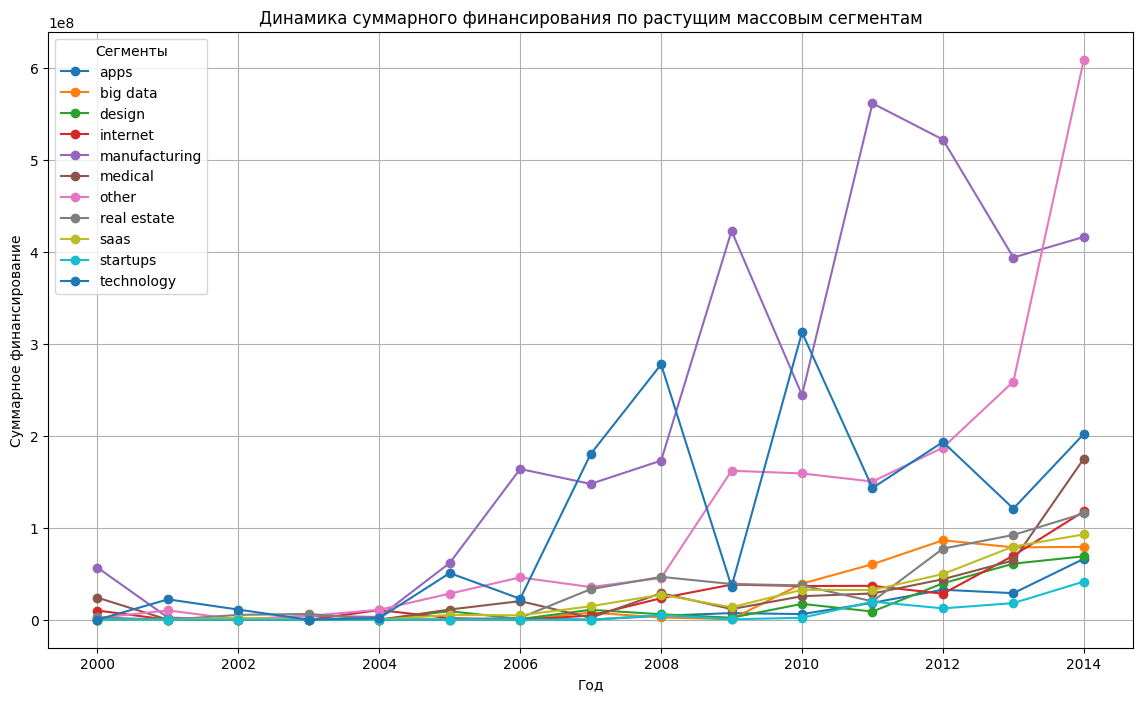

In [71]:
# Задаем размер графика
plt.figure(figsize=(14, 8))

# Перебираем все сегменты рынка из таблицы pivot_growing
for market in pivot_growing.columns:
    # Строим линию графика для текущего сегмента рынка
    plt.plot(
        pivot_growing.index,
        pivot_growing[market],
        marker='o',
        label=market
    )

# Настраиваем оформление графика
plt.title('Динамика суммарного финансирования по растущим массовым сегментам')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование')

# Добавляем сетку графика
plt.grid()

# Добавляем легенду
plt.legend(title='Сегменты')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- За период с 2000 по 2014 год наблюдается значительный рост суммарного финансирования практически во всех сегментах

- Особенно заметен рост после 2006–2008 гг.

- Сегмент `manufacturing` — демонстрирует самый высокий уровень финансирования к концу периода

- Сегмент `other` — также показывает значительный рост, особенно к 2014 году

- `apps`, `big data`, `saas` — показывают устойчивый, но менее взрывной рост.

- `medical` и `internet` — демонстрируют плавный рост с периодическими всплесками

- `design`, `real estate`, `startups` — остаются на более низком уровне по сравнению с другими сегментами 

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [72]:
# Определяем список типов финансирования, которые будем анализировать
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [73]:
# Создаём сводную таблицу по годам с суммированием значений для каждого типа финансирования из списка funding_cols
funding_pivot = cb_investments.groupby('mid_funding_year')[funding_cols].sum()

In [74]:
# Присваиваем переменной returns_pivot данные о доходности из cb_returns.
returns_pivot = cb_returns

In [75]:
# Находим пересечение (общие значения) между двумя таблицами
common_years = funding_pivot.index.intersection(returns_pivot.index)

# Находим пересечение (общие столбцы) между двумя таблицами 
common_types = funding_pivot.columns.intersection(returns_pivot.columns)

# Фильтруем таблицы funding_pivot и returns_pivot, оставляя только:общие годы и общие типы финансирования
funding_filtered = funding_pivot.loc[common_years, common_types]
returns_filtered = returns_pivot.loc[common_years, common_types]

In [76]:
# Создаём пустую таблицу normalized для хранения нормализованных данных.
normalized = pd.DataFrame(index=common_years, columns=common_types)

# Проходим по каждому году из common_years и каждому типу финансирования из common_types,
# вычисляя отношение доходности к объёму финансирования (нормализацию)
for year in common_years:
    for fin_type in common_types:
        # Извлекаем значение доходности для текущего года и типа финансирования
        returns = returns_filtered.loc[year, fin_type]
        # Извлекаем значение объёма финансирования для текущего года и типа финансирования.
        funding = funding_filtered.loc[year, fin_type]
        
        # Вычисляем отношение доходности к финансированию и добавляем 1e-60 к знаменателю, чтобы избежать деления на ноль.
        ratio = returns / (funding + 1e-60)
        
        # Фильтруем аномальные значения отношения
        if -1 <= ratio <= 10:
            normalized.loc[year, fin_type] = ratio
        else:
            normalized.loc[year, fin_type] = np.nan

In [77]:
# Удаляем строки, где все значения — NaN и сортируем получившуюся таблицу по индекс
normalized = normalized.dropna(how='all').sort_index()

# Выводим результат
print("Нормированные значения возврата средств (доля от вложенных):")
print(normalized)

Нормированные значения возврата средств (доля от вложенных):
          seed   venture equity_crowdfunding undisclosed convertible_note  \
2000  0.000001       0.0                 0.0    0.000001              0.0   
2001  0.000001       0.0                 0.0    0.000001              0.0   
2002  0.000001  0.000001                 0.0    0.000001              NaN   
2003  0.000001  0.000001                 0.0    0.000001              NaN   
2004  0.000001  0.000001                 0.0    0.000001              NaN   
2005  0.000001  0.000001                 0.0    0.000001              NaN   
2006  0.000001       0.0                 0.0    0.000001              0.0   
2007       0.0       0.0                 NaN    0.000001              0.0   
2008       0.0       0.0                 NaN         0.0              0.0   
2009  0.000001       0.0                 0.0         0.0              0.0   
2010  0.000001       0.0                 0.0         0.0              0.0   
2011       0.0 

<Figure size 1400x800 with 0 Axes>

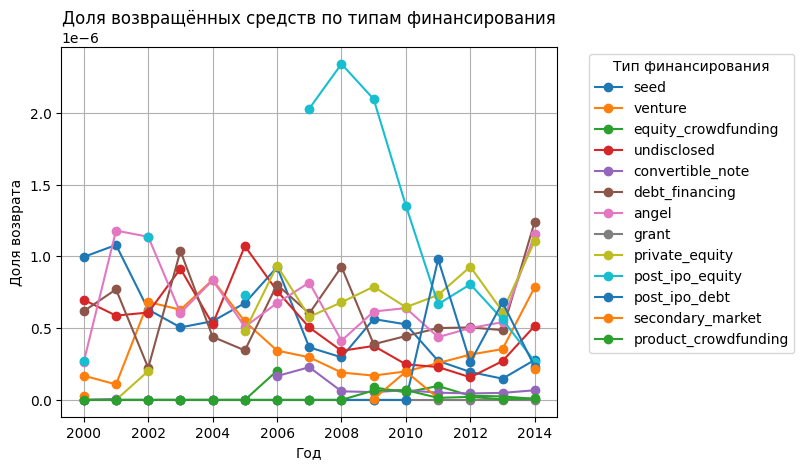

In [78]:
# Задаем размер графика
plt.figure(figsize=(14, 8))

# Создаём линейный график
normalized.plot(kind='line',
                marker='o',
                label=market)

# Настраиваем оформление графика
plt.title('Доля возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')

# Добавляем легенду за пределы чарта
plt.legend(title='Тип финансирования', bbox_to_anchor=(1.05, 1), loc='upper left')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наиболее заметные пики и спады наблюдаются в период с 2008 по 2012 год

- `post_ipo_equity` демонстрирует самые высокие значения доли возврата

- `debt_financing` также показывает относительно высокие значения

## 5. Итоговый вывод и рекомендации

В ходе исследования был проведён анализ данных о финансировании стартапов, включающий информацию об объёмах и типах привлечённых инвестиций, стадиях развития компаний, а также о суммах и динамике возвратов средств по различным механизмам финансирования.

### Фокус был сделан на изучении:

- распределения инвестиций по стадиям и типам финансирования;

- динамики объёмов привлечённых средств и возвратов по годам;

- соотношения между объёмами вложений и фактическими возвратами по категориям инвестиций;

- аномалий и выбросов в данных (например, крайне высокие возвраты по отдельным типам финансирования).

### Общий профиль рынка венчурных инвестиций:

Анализ позволил сформировать ключевые характеристики рынка:

- наиболее распространённые типы финансирования — venture (венчурные инвестиции) и seed (посевные инвестиции): они лидируют по количеству сделок и совокупному объёму привлечённых средств.

- значимую долю рынка занимают private_equity и debt_financing

- наименьшие объёмы привлечения и возвратов наблюдаются по механизмам equity_crowdfunding, product_crowdfunding и grant

### Рекомендации

- Сформировать сбалансированный портфель по стадиям инвестирования:

    - 50–60 % — поздние стадии (post_ipo_equity, private_equity, debt_financing): обеспечивают стабильность и предсказуемую доходность.

    - 30–40 % — ранние стадии (venture, seed): потенциал сверхдоходности при грамотном отборе проектов.

    - ≤ 10 % — альтернативные механизмы (equity_crowdfunding, product_crowdfunding, grant): только для нишевых стратегий с чёткими критериями отбора.

- Для стартапов выбирать тип финансирования по стадии развития:

    - seed/angel — для первых продаж (доказательство концепции);

    - venture — для масштабирования (выход на новые рынки, увеличение штата);

    - private_equity/debt_financing — для зрелых компаний (оптимизация процессов, покупка активов).